In [1]:
import sys, platform, multiprocessing

print("Python   :", sys.version.split()[0])
print("OS       :", platform.platform())
print("CPU core :", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

Python   : 3.13.15
OS       : Linux-6.6.122+-x86_64-with-glibc2.39
CPU core : 2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
matplotlib : 3.10.0


In [2]:
!free -h
!df -h /content
!java -version

               total        used        free      shared  buff/cache   available
Mem:            12Gi       974Mi       8.9Gi       2.1Mi       3.1Gi        11Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  19% /
[0.027s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.027s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


In [3]:
from google.colab import drive
drive.mount("/content/drive")

import os
DIR_KERJA = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"

os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)

print("Folder simpan:", DIR_SIMPAN)
print("Isi folder:", os.listdir(DIR_SIMPAN))

Mounted at /content/drive
Folder simpan: /content/drive/MyDrive/BigData/Praktikum1
Isi folder: ['agregasi_per_jam.csv', 'distribusi_per_jam.png', 'rekomendasi_studi_kasus.txt', 'studi_kasus_tarif_per_menit.png', 'agregasi_per_jam.parquet', 'studi_kasus_weekday_weekend.png', 'Laporan_Praktikum_BigData_P01_<NIM>.pdf', 'perbandingan_januari_juli_per_jam.csv', 'agregasi_per_jam_2023-07.csv', 'perbandingan_januari_juli.png', 'distribusi_per_jam_2023-07.png', 'agregasi_per_jam_2023-07.parquet', 'pengukuran_kinerja.csv']


In [4]:
import time, os, psutil

proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    delta = rss_mb() - m0
    catatan.append({
        "langkah": label,
        "detik": round(detik, 2),
        "delta_rss_mb": round(delta, 1)
    })
    print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
    return hasil

In [5]:
import urllib.request

URL = ("https://d37ci6vzurychx.cloudfront.net/trip-data/"
       "yellow_tripdata_2023-01.parquet")
PATH = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")

if not os.path.exists(PATH):
    ukur("unduh dataset", lambda: urllib.request.urlretrieve(URL, PATH))

print("Ukuran file:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")

[unduh dataset] 0.33 s | RSS +1.6 MB
Ukuran file: 45.5 MB


In [6]:
import pyarrow.parquet as pq

meta = pq.ParquetFile(PATH).metadata
print("Jumlah baris :", f"{meta.num_rows:,}")
print("Jumlah kolom :", meta.num_columns)
print("Row group    :", meta.num_row_groups)
print("Nama kolom   :", pq.ParquetFile(PATH).schema.names)

Jumlah baris : 3,066,766
Jumlah kolom : 19
Row group    : 1
Nama kolom   : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


In [7]:
# JALANKAN HANYA JIKA DATASET ASLI GAGAL DIUNDUH.
# Jangan jalankan bila PATH dari J-4 sudah berhasil.

import numpy as np, pandas as pd

def bangkitkan_sintetis(n=5_000_000, seed=42):
    rng = np.random.default_rng(seed)
    awal = pd.Timestamp("2023-01-01")
    pickup = awal + pd.to_timedelta(rng.integers(0, 31*24*60, n), unit="m")
    durasi = rng.integers(1, 90, n)

    return pd.DataFrame({
        "tpep_pickup_datetime": pickup,
        "tpep_dropoff_datetime": pickup + pd.to_timedelta(durasi, unit="m"),
        "passenger_count": rng.integers(1, 5, n).astype("float64"),
        "trip_distance": np.round(rng.gamma(2.0, 1.6, n), 2),
        "payment_type": rng.integers(1, 5, n).astype("int64"),
        "fare_amount": np.round(rng.gamma(4.0, 3.0, n), 2),
        "tip_amount": np.round(rng.gamma(1.5, 1.2, n), 2),
    }).assign(total_amount=lambda d: (d.fare_amount + d.tip_amount + 3.0).round(2))

# Contoh pemakaian:
# bangkitkan_sintetis().to_parquet(PATH, index=False)
# print("Dataset sintetis dibuat di", PATH)

In [8]:
import pandas as pd
import gc

KOLOM = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "passenger_count", "trip_distance", "payment_type",
    "fare_amount", "tip_amount", "total_amount"
]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))
print("Dimensi:", penuh.shape)
print("Memori :", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

mem_penuh = penuh.memory_usage(deep=True).sum() / 1024**2
jumlah_kolom_penuh = penuh.shape[1]

del penuh
gc.collect()

df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori :", round(df.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

mem_terpilih = df.memory_usage(deep=True).sum() / 1024**2
df.head()

[baca semua kolom] 1.53 s | RSS +498.4 MB
Dimensi: (3066766, 19)
Memori : 565.6 MB
[baca kolom terpilih] 0.58 s | RSS +204.6 MB
Dimensi: (3066766, 8)
Memori : 187.2 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,2,9.3,0.00,14.30
1,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1,7.9,4.00,16.90
2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1,14.9,15.00,34.90
3,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1,12.1,0.00,20.85
4,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1,11.4,3.28,19.68


In [9]:
df.info(memory_usage="deep")
(df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2).rename("MB per kolom")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 187.2 MB


,MB per kolom
tpep_pickup_datetime,23.397568
payment_type,23.397568
tpep_dropoff_datetime,23.397568
passenger_count,23.397568
trip_distance,23.397568
tip_amount,23.397568
fare_amount,23.397568
total_amount,23.397568
Index,0.000126


In [10]:
sebelum = df.memory_usage(deep=True).sum() / 1024**2

df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"] = pd.to_numeric(df["payment_type"], downcast="integer").astype("category")

for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
hemat_tipe_persen = 100 * (1 - sesudah / sebelum)

print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB (hemat {hemat_tipe_persen:.1f}%)")
df.dtypes

187.2 MB -> 119.9 MB (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


In [11]:
df["durasi_menit"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <= 0": (df["trip_distance"] <= 0).sum(),
    "durasi <= 0": (df["durasi_menit"] <= 0).sum(),
    "durasi > 180 menit": (df["durasi_menit"] > 180).sum(),
    "total_amount <= 0": (df["total_amount"] <= 0).sum(),
}

for k, v in anomali.items():
    print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

       trip_distance  durasi_menit  total_amount
count   3.066766e+06  3.066766e+06  3.066766e+06
mean    3.847342e+00  1.566900e+01  2.702038e+01
std     2.495838e+02  4.259435e+01  2.212666e+01
min     0.000000e+00 -2.920000e+01 -7.510000e+02
25%     1.060000e+00  7.116667e+00  1.540000e+01
50%     1.800000e+00  1.151667e+01  2.016000e+01
75%     3.330000e+00  1.830000e+01  2.870000e+01
max     2.589281e+05  1.002918e+04  1.169400e+03

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 45,862 baris (1.50%)
durasi <= 0           : 1,121 baris (0.04%)
durasi > 180 menit    : 3,048 baris (0.10%)
total_amount <= 0     : 25,772 baris (0.84%)


In [12]:
layak = (
    (df["trip_distance"] > 0) &
    (df["trip_distance"] < 100) &
    (df["durasi_menit"].between(1, 180)) &
    (df["total_amount"] > 0)
)

bersih = df.loc[layak].copy()
baris_dibuang = len(df) - len(bersih)
persen_dibuang = 100 * baris_dibuang / len(df)

print(f"{len(df):,} baris -> {len(bersih):,} baris "
      f"(dibuang {baris_dibuang:,} = {persen_dibuang:.2f}%)")

3,066,766 baris -> 2,986,911 baris (dibuang 79,855 = 2.60%)


In [13]:
CSV = os.path.join(DIR_KERJA, "trips.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))

ukuran_parquet_mb = os.path.getsize(PATH) / 1024**2
ukuran_csv_mb = os.path.getsize(CSV) / 1024**2

print("Parquet:", round(ukuran_parquet_mb, 1), "MB")
print("CSV    :", round(ukuran_csv_mb, 1), "MB")
print("Rasio CSV/Parquet:", round(ukuran_csv_mb / ukuran_parquet_mb, 2), "x")

[tulis CSV] 39.27 s | RSS +5.8 MB
Parquet: 45.5 MB
CSV    : 226.2 MB
Rasio CSV/Parquet: 4.98 x


In [14]:
def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai = 0.0
    per_jam = {}

    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk
    )

    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai += chunk["total_amount"].sum()

        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())

    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur(
    "agregasi chunking",
    lambda: agregasi_bertahap(CSV)
)

print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[agregasi chunking] 4.05 s | RSS +20.4 MB
2,986,911 baris | rata-rata total_amount = 27.33


In [15]:
!pip install -q pyspark==3.5.1
!java -version

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 14.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


In [16]:
from pyspark.sql import SparkSession, functions as F

spark = (
    SparkSession.builder
    .appName("BD-P01")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

Spark: 3.5.1


In [18]:
sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (
    sdf
    .withColumn(
        "durasi_menit",
        (
            F.unix_timestamp(F.col("tpep_dropoff_datetime"))
            - F.unix_timestamp(F.col("tpep_pickup_datetime"))
        ) / 60
    )
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0)
)

hasil_spark = (
    sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(
        F.count("*").alias("jumlah"),
        F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
        F.round(F.avg("total_amount"), 2).alias("rata_tarif")
    )
    .orderBy("jam")
)

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)

[spark count] 0.34 s | RSS +0.0 MB
Jumlah baris: 3066766
+---+------+----------+----------+
|jam|jumlah|rata_jarak|rata_tarif|
+--

In [19]:
sdf_bersih.createOrReplaceTempView("trips")

spark.sql("""
    SELECT payment_type,
           COUNT(*) AS jumlah,
           ROUND(AVG(total_amount), 2) AS rata_tarif,
           ROUND(AVG(tip_amount), 2) AS rata_tip
    FROM trips
    GROUP BY payment_type
    ORDER BY jumlah DESC
""").show()

hasil_spark.explain()

+------------+-------+----------+--------+
|payment_type| jumlah|rata_tarif|rata_tip|
+------------+-------+----------+--------+
|           1|2385064|      28.1|    4.16|
|           2| 512987|     23.58|     0.0|
|           0|  64106|     29.82|    4.06|
|           4|  15570|     24.11|    0.02|
|           3|   9184|     22.63|     0.0|
+------------+-------+----------+--------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [jam#147 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(jam#147 ASC NULLS FIRST, 8), ENSURE_REQUIREMENTS, [plan_id=241]
      +- HashAggregate(keys=[jam#147], functions=[count(1), avg(trip_distance#67), avg(total_amount#79)])
         +- Exchange hashpartitioning(jam#147, 8), ENSURE_REQUIREMENTS, [plan_id=238]
            +- HashAggregate(keys=[jam#147], functions=[partial_count(1), partial_avg(trip_distance#67), partial_avg(total_amount#79)])
               +- Project [trip_distance#67, total_amount#79, hour(tpep_pickup_datetime#

## J-9. Agregasi akhir dengan pandas dan penyimpanan artefak

Output utama:
- `agregasi_per_jam.csv`
- `agregasi_per_jam.parquet`
- `pengukuran_kinerja.csv`

In [20]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (
    bersih
    .groupby("jam")
    .agg(
        jumlah_perjalanan=("total_amount", "size"),
        rata_jarak=("trip_distance", "mean"),
        rata_durasi=("durasi_menit", "mean"),
        rata_tarif=("total_amount", "mean"),
        median_tarif=("total_amount", "median")
    )
    .round(2)
    .reset_index()
)

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)

pengukuran_kinerja = pd.DataFrame(catatan)
pengukuran_kinerja.to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

display(agregasi)
display(pengukuran_kinerja)

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,82289,4.04,13.57,28.860001,21.600000
1,1,57766,3.53,12.63,26.450001,21.200001
2,2,40445,3.28,12.07,25.059999,20.520000
3,3,26146,3.58,12.15,26.260000,21.000000
4,4,16618,4.79,13.52,31.719999,22.700001
5,5,16940,6.03,14.70,36.750000,22.040001
6,6,42300,4.80,14.49,30.629999,18.480000
7,7,84569,3.69,14.42,26.889999,18.480000
8,8,114064,3.08,14.33,25.209999,19.100000
9,9,127988,3.09,14.23,25.510000,19.250000


,langkah,detik,delta_rss_mb
0,unduh dataset,0.33,1.6
1,baca semua kolom,1.53,498.4
2,baca kolom terpilih,0.58,204.6
3,tulis CSV,39.27,5.8
4,agregasi chunking,4.05,20.4
5,spark count,8.05,0.0
6,spark count,0.34,0.0
7,spark agregasi,7.83,0.0


## J-10. Visualisasi hasil

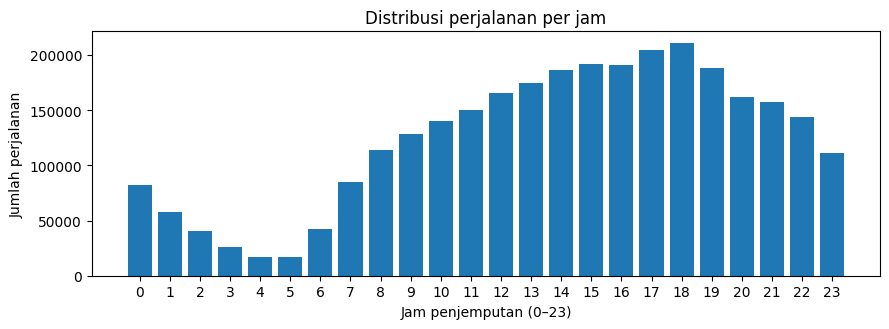

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi["jam"], agregasi["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0–23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
ax.set_xticks(range(0, 24))
fig.tight_layout()

fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam.png", dpi=150)
plt.show()

# N. Analisis Hasil

Sel berikut menghasilkan angka yang dipakai untuk menulis analisis. Gunakan pola **satu klaim, satu angka, satu alasan**.

In [22]:
rasio_memori = mem_penuh / mem_terpilih
rasio_kolom = jumlah_kolom_penuh / len(KOLOM)
rasio_csv_parquet = ukuran_csv_mb / ukuran_parquet_mb

print("1) Rasio memori semua kolom / kolom terpilih :", round(rasio_memori, 2), "x")
print("   Rasio jumlah kolom penuh / kolom dipakai  :", round(rasio_kolom, 2), "x")
print("2) Penghematan optimasi tipe data             :", round(hemat_tipe_persen, 2), "%")
print("3) Rasio ukuran CSV / Parquet                 :", round(rasio_csv_parquet, 2), "x")
print("4) Baris dibuang                              :", f"{persen_dibuang:.2f}%")
print("\nPengukuran kinerja:")
display(pd.DataFrame(catatan))

1) Rasio memori semua kolom / kolom terpilih : 3.02 x
   Rasio jumlah kolom penuh / kolom dipakai  : 2.38 x
2) Penghematan optimasi tipe data             : 35.94 %
3) Rasio ukuran CSV / Parquet                 : 4.98 x
4) Baris dibuang                              : 2.60%

Pengukuran kinerja:


,langkah,detik,delta_rss_mb
0,unduh dataset,0.33,1.6
1,baca semua kolom,1.53,498.4
2,baca kolom terpilih,0.58,204.6
3,tulis CSV,39.27,5.8
4,agregasi chunking,4.05,20.4
5,spark count,8.05,0.0
6,spark count,0.34,0.0
7,spark agregasi,7.83,0.0


### Panduan jawaban Analisis Hasil

1. **Biaya membaca data:** bandingkan durasi/RSS pada `baca semua kolom` dan `baca kolom terpilih`. Perbedaannya tidak harus sama persis dengan rasio jumlah kolom karena ada overhead metadata, buffer reader, indeks, dan biaya tetap proses.
2. **Optimasi tipe:** gunakan persentase yang tercetak. Penghematan berasal dari tipe lebih kecil dan `category`. Risiko utama `float32` adalah presisi lebih rendah.
3. **CSV vs Parquet:** gunakan rasio ukuran yang tercetak. CSV berupa teks dan tidak memiliki kompresi/encoding kolumnar seefisien Parquet.
4. **Chunking:** bandingkan `delta_rss_mb`. Chunking menghemat RAM tetapi menambah overhead iterasi dan biasanya waktu proses.
5. **pandas vs Spark:** pada data satu bulan ini pandas sering lebih ringan karena Spark memiliki overhead scheduler/serialisasi. Jangan mengklaim angka sebelum melihat hasil runtime.
6. **Kualitas data:** gunakan `% baris dibuang`. Jelaskan bahwa filter dapat menimbulkan bias bila perjalanan ekstrem yang sebenarnya valid ikut terhapus.

# O. Studi Kasus — Penjadwalan Armada

Menjawab:
1. jam permintaan tertinggi dan terendah,
2. perbedaan hari kerja vs akhir pekan,
3. apakah jam sibuk cenderung lebih pendek dan lebih menguntungkan per menit.

In [23]:
import numpy as np

bersih["hari"] = bersih["tpep_pickup_datetime"].dt.day_name()
bersih["akhir_pekan"] = bersih["tpep_pickup_datetime"].dt.dayofweek >= 5
bersih["tarif_per_menit"] = np.where(
    bersih["durasi_menit"] > 0,
    bersih["total_amount"] / bersih["durasi_menit"],
    np.nan
)

ringkas = (
    bersih
    .groupby(["akhir_pekan", "jam"])
    .agg(
        jumlah=("total_amount", "size"),
        rata_durasi=("durasi_menit", "mean"),
        rata_tarif_per_menit=("tarif_per_menit", "mean")
    )
    .round(2)
    .reset_index()
)

display(ringkas)

per_jam_total = bersih.groupby("jam").size()
jam_tertinggi = int(per_jam_total.idxmax())
jam_terendah = int(per_jam_total.idxmin())
nilai_tertinggi = int(per_jam_total.max())
nilai_terendah = int(per_jam_total.min())

print(f"Permintaan tertinggi: jam {jam_tertinggi:02d}:00 = {nilai_tertinggi:,} perjalanan")
print(f"Permintaan terendah : jam {jam_terendah:02d}:00 = {nilai_terendah:,} perjalanan")

,akhir_pekan,jam,jumlah,rata_durasi,rata_tarif_per_menit
0,False,0,35351,14.10,2.57
1,False,1,17516,13.04,2.66
2,False,2,9452,12.23,2.63
3,False,3,6238,12.87,2.72
4,False,4,6192,14.79,2.81
5,False,5,12462,14.63,2.82
6,False,6,35728,14.57,2.33
7,False,7,74157,14.66,2.07
8,False,8,98431,14.82,1.90
9,False,9,103263,15.03,1.90


Permintaan tertinggi: jam 18:00 = 210,858 perjalanan
Permintaan terendah : jam 04:00 = 16,618 perjalanan


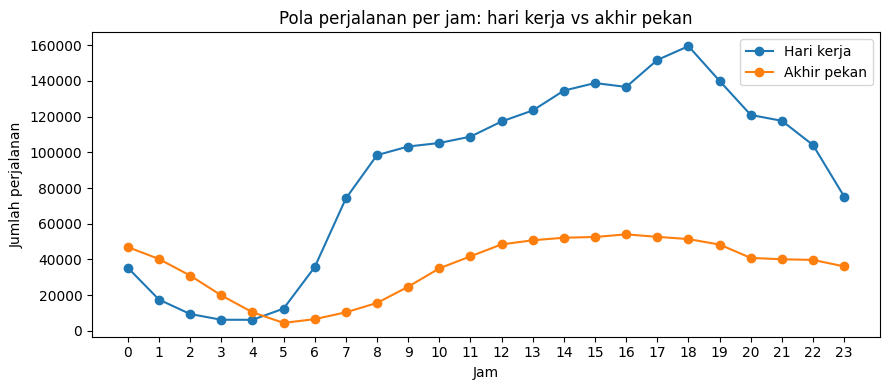

In [24]:
# Grafik 1: pola jumlah perjalanan hari kerja vs akhir pekan
pivot_jumlah = ringkas.pivot(index="jam", columns="akhir_pekan", values="jumlah").fillna(0)
pivot_jumlah.columns = ["Hari kerja" if c is False else "Akhir pekan" for c in pivot_jumlah.columns]

ax = pivot_jumlah.plot(figsize=(9, 4), marker="o")
ax.set_title("Pola perjalanan per jam: hari kerja vs akhir pekan")
ax.set_xlabel("Jam")
ax.set_ylabel("Jumlah perjalanan")
ax.set_xticks(range(24))
plt.tight_layout()
plt.savefig(f"{DIR_SIMPAN}/studi_kasus_harikerja_vs_akhirpekan.png", dpi=150)
plt.show()

In [25]:
# Definisi jam sibuk: 3 jam dengan jumlah perjalanan paling besar.
jam_sibuk = per_jam_total.nlargest(3).index.tolist()
bersih["is_jam_sibuk"] = bersih["jam"].isin(jam_sibuk)

banding_sibuk = (
    bersih.groupby("is_jam_sibuk")
    .agg(
        jumlah=("total_amount", "size"),
        rata_durasi=("durasi_menit", "mean"),
        rata_tarif_per_menit=("tarif_per_menit", "mean")
    )
    .round(2)
)

display(banding_sibuk)
print("Tiga jam tersibuk:", sorted(jam_sibuk))

,jumlah,rata_durasi,rata_tarif_per_menit
is_jam_sibuk,,,
False,2380262,14.34,2.14
True,606649,15.52,2.04


Tiga jam tersibuk: [15, 17, 18]


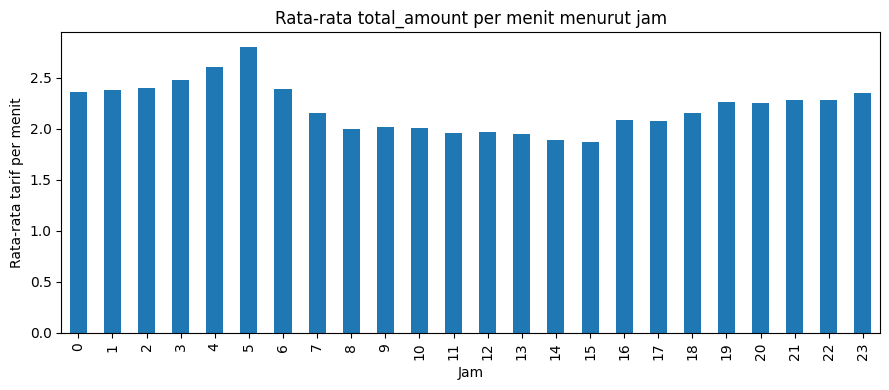

In [26]:
# Grafik 2: rata-rata tarif per menit menurut jam
tarif_jam = bersih.groupby("jam")["tarif_per_menit"].mean()

ax = tarif_jam.plot(kind="bar", figsize=(9, 4))
ax.set_title("Rata-rata total_amount per menit menurut jam")
ax.set_xlabel("Jam")
ax.set_ylabel("Rata-rata tarif per menit")
plt.tight_layout()
plt.savefig(f"{DIR_SIMPAN}/studi_kasus_tarif_per_menit.png", dpi=150)
plt.show()

In [27]:
# Tiga rekomendasi operasional otomatis berdasarkan hasil runtime
weekday_total = ringkas.loc[~ringkas["akhir_pekan"], "jumlah"].sum()
weekend_total = ringkas.loc[ringkas["akhir_pekan"], "jumlah"].sum()

sibuk = banding_sibuk.loc[True]
non_sibuk = banding_sibuk.loc[False]

print("REKOMENDASI OPERASIONAL")
print(
    f"1. Tambahkan kapasitas armada di sekitar jam {jam_tertinggi:02d}:00 karena "
    f"tercatat {nilai_tertinggi:,} perjalanan; batasannya data hanya mewakili satu bulan."
)
print(
    f"2. Pola hari kerja dan akhir pekan perlu dijadwalkan terpisah karena total sampelnya "
    f"{int(weekday_total):,} vs {int(weekend_total):,} perjalanan; batasannya jumlah hari kerja "
    f"dan akhir pekan dalam bulan tidak sama."
)
print(
    f"3. Pada tiga jam tersibuk {sorted(jam_sibuk)}, rata-rata durasi {sibuk['rata_durasi']:.2f} menit "
    f"dan tarif/menit {sibuk['rata_tarif_per_menit']:.2f}; sebagai pembanding jam lain "
    f"{non_sibuk['rata_durasi']:.2f} menit dan {non_sibuk['rata_tarif_per_menit']:.2f}. "
    f"Batasannya total_amount bukan laba bersih operator."
)

REKOMENDASI OPERASIONAL
1. Tambahkan kapasitas armada di sekitar jam 18:00 karena tercatat 210,858 perjalanan; batasannya data hanya mewakili satu bulan.
2. Pola hari kerja dan akhir pekan perlu dijadwalkan terpisah karena total sampelnya 2,132,583 vs 854,328 perjalanan; batasannya jumlah hari kerja dan akhir pekan dalam bulan tidak sama.
3. Pada tiga jam tersibuk [15, 17, 18], rata-rata durasi 15.52 menit dan tarif/menit 2.04; sebagai pembanding jam lain 14.34 menit dan 2.14. Batasannya total_amount bukan laba bersih operator.


# P. Latihan

## Latihan 1 — 5 nilai `trip_distance` terbesar

In [28]:
terbesar_5 = bersih.nlargest(5, "trip_distance")
display(terbesar_5)

print(
    "Komentar: kelima baris masih lolos filter <100 mil, tetapi perlu diperiksa konteksnya "
    "karena jarak ekstrem bisa merupakan perjalanan nyata maupun pencatatan tidak biasa."
)

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount,durasi_menit,jam,hari,akhir_pekan,tarif_per_menit,is_jam_sibuk
1748933,2023-01-19 16:29:36,2023-01-19 18:46:01,1.0,96.70,1,350.000000,50.0,440.750000,136.416667,16,Thursday,False,3.230910,False
526988,2023-01-07 04:29:56,2023-01-07 06:06:16,2.0,93.05,2,542.000000,0.0,564.049988,96.333333,4,Saturday,True,5.855190,False
2402193,2023-01-26 04:55:45,2023-01-26 07:18:50,1.0,92.60,1,262.500000,20.0,312.799988,143.083333,4,Thursday,False,2.186139,False
2902389,2023-01-31 07:04:24,2023-01-31 09:32:54,1.0,92.00,1,334.100006,10.0,368.149994,148.500000,7,Tuesday,False,2.479125,False
927215,2023-01-11 14:23:55,2023-01-11 16:17:58,1.0,90.63,2,250.000000,0.0,272.299988,114.050000,14,Wednesday,False,2.387549,False


Komentar: kelima baris masih lolos filter <100 mil, tetapi perlu diperiksa konteksnya karena jarak ekstrem bisa merupakan perjalanan nyata maupun pencatatan tidak biasa.


## Latihan 2 — Chunk size 100.000 vs 1.000.000

In [29]:
hasil_chunk = []

for ukuran in [100_000, 1_000_000]:
    m0, t0 = rss_mb(), time.perf_counter()
    b, total, pj = agregasi_bertahap(CSV, ukuran_chunk=ukuran)
    detik = time.perf_counter() - t0
    delta = rss_mb() - m0
    hasil_chunk.append({
        "chunksize": ukuran,
        "detik": round(detik, 2),
        "delta_rss_mb": round(delta, 1),
        "jumlah_baris": b
    })

hasil_chunk_df = pd.DataFrame(hasil_chunk)
display(hasil_chunk_df)

print(
    "Trade-off: chunk lebih kecil cenderung menekan memori tetapi menambah jumlah iterasi; "
    "chunk lebih besar dapat mengurangi overhead iterasi tetapi membutuhkan memori lebih besar."
)

,chunksize,detik,delta_rss_mb,jumlah_baris
0,100000,4.25,51.9,2986911
1,1000000,4.22,79.3,2986911


Trade-off: chunk lebih kecil cenderung menekan memori tetapi menambah jumlah iterasi; chunk lebih besar dapat mengurangi overhead iterasi tetapi membutuhkan memori lebih besar.


## Latihan 3 — Persentase tip per `payment_type`

In [30]:
bersih["persen_tip"] = np.where(
    bersih["fare_amount"] != 0,
    bersih["tip_amount"] / bersih["fare_amount"] * 100,
    np.nan
)

tip_per_payment = (
    bersih.groupby("payment_type", observed=False)["persen_tip"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

display(tip_per_payment.to_frame("rata_persen_tip"))

print(
    "Dugaan: perbedaan dapat muncul karena perilaku pembayaran dan pencatatan tip berbeda "
    "antar-metode. Interpretasi sebaiknya mengacu pada definisi payment_type di data dictionary."
)

,rata_persen_tip
payment_type,
1,25.910000
0,20.219999
4,0.150000
3,0.020000
2,0.000000


Dugaan: perbedaan dapat muncul karena perilaku pembayaran dan pencatatan tip berbeda antar-metode. Interpretasi sebaiknya mengacu pada definisi payment_type di data dictionary.


## Latihan 4 — Parquet Snappy vs Gzip

In [31]:
hasil_kompresi = []

for kompresi in ["snappy", "gzip"]:
    tujuan = f"{DIR_SIMPAN}/bersih_{kompresi}.parquet"
    t0 = time.perf_counter()
    bersih.to_parquet(tujuan, index=False, compression=kompresi)
    detik = time.perf_counter() - t0
    ukuran = os.path.getsize(tujuan) / 1024**2

    hasil_kompresi.append({
        "kompresi": kompresi,
        "waktu_tulis_detik": round(detik, 2),
        "ukuran_mb": round(ukuran, 2)
    })

display(pd.DataFrame(hasil_kompresi))

print(
    "Umumnya gzip menghasilkan file lebih kecil tetapi waktu tulis lebih lama; "
    "Snappy biasanya lebih cepat dengan rasio kompresi lebih ringan. Gunakan hasil runtime sebagai bukti."
)

,kompresi,waktu_tulis_detik,ukuran_mb
0,snappy,3.01,80.40
1,gzip,48.93,65.14


Umumnya gzip menghasilkan file lebih kecil tetapi waktu tulis lebih lama; Snappy biasanya lebih cepat dengan rasio kompresi lebih ringan. Gunakan hasil runtime sebagai bukti.


## Latihan 5 — Agregasi per jam dengan Spark SQL dan uji konsistensi

In [32]:
# Pastikan Spark aktif kembali bila sebelumnya dihentikan.
try:
    spark.version
except:
    spark = (
        SparkSession.builder
        .appName("BD-P01-Latihan5")
        .master("local[*]")
        .config("spark.sql.shuffle.partitions", "8")
        .getOrCreate()
    )

sdf_bersih.createOrReplaceTempView("trips")

spark_jam = spark.sql("""
    SELECT HOUR(tpep_pickup_datetime) AS jam,
           COUNT(*) AS jumlah_perjalanan
    FROM trips
    GROUP BY HOUR(tpep_pickup_datetime)
    ORDER BY jam
""")

spark_jam_pd = spark_jam.toPandas()
banding = agregasi[["jam", "jumlah_perjalanan"]].merge(
    spark_jam_pd,
    on="jam",
    suffixes=("_pandas", "_spark")
)

banding["selisih"] = (
    banding["jumlah_perjalanan_pandas"] - banding["jumlah_perjalanan_spark"]
).abs()

display(banding)
print("Selisih maksimum:", banding["selisih"].max())

,jam,jumlah_perjalanan_pandas,jumlah_perjalanan_spark,selisih
0,0,82289,82289,0
1,1,57766,57766,0
2,2,40445,40445,0
3,3,26146,26146,0
4,4,16618,16618,0
5,5,16940,16940,0
6,6,42300,42300,0
7,7,84569,84569,0
8,8,114064,114064,0
9,9,127988,127988,0


Selisih maksimum: 0


# Q. Tugas Praktikum

Untuk dataset pengganti dipakai **Yellow Taxi Juli 2023**, sesuai contoh yang diberikan modul.

## Q1 — Ulangi pengolahan pada dataset Juli 2023

In [33]:
URL_JULI = ("https://d37ci6vzurychx.cloudfront.net/trip-data/"
            "yellow_tripdata_2023-07.parquet")
PATH_JULI = os.path.join(DIR_KERJA, "yellow_tripdata_2023-07.parquet")

if not os.path.exists(PATH_JULI):
    ukur("unduh dataset Juli", lambda: urllib.request.urlretrieve(URL_JULI, PATH_JULI))

meta_juli = pq.ParquetFile(PATH_JULI).metadata
print("Ukuran file:", round(os.path.getsize(PATH_JULI)/1024**2, 1), "MB")
print("Jumlah baris:", f"{meta_juli.num_rows:,}")
print("Jumlah kolom:", meta_juli.num_columns)
print("Nama kolom:", pq.ParquetFile(PATH_JULI).schema.names)

[unduh dataset Juli] 0.34 s | RSS +0.0 MB
Ukuran file: 46.1 MB
Jumlah baris: 2,907,108
Jumlah kolom: 19
Nama kolom: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


In [34]:
def proses_dataset_bulanan(path, label):
    temp = ukur(
        f"baca {label} kolom terpilih",
        lambda: pd.read_parquet(path, columns=KOLOM)
    )

    # Optimasi tipe
    temp["passenger_count"] = pd.to_numeric(temp["passenger_count"], downcast="float")
    temp["payment_type"] = pd.to_numeric(
        temp["payment_type"], downcast="integer"
    ).astype("category")
    for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
        temp[kol] = pd.to_numeric(temp[kol], downcast="float")

    temp["durasi_menit"] = (
        temp["tpep_dropoff_datetime"] - temp["tpep_pickup_datetime"]
    ).dt.total_seconds() / 60

    layak = (
        (temp["trip_distance"] > 0) &
        (temp["trip_distance"] < 100) &
        (temp["durasi_menit"].between(1, 180)) &
        (temp["total_amount"] > 0)
    )

    clean = temp.loc[layak].copy()
    clean["jam"] = clean["tpep_pickup_datetime"].dt.hour

    agg = (
        clean.groupby("jam")
        .agg(
            jumlah_perjalanan=("total_amount", "size"),
            rata_jarak=("trip_distance", "mean"),
            rata_durasi=("durasi_menit", "mean"),
            rata_tarif=("total_amount", "mean"),
            median_tarif=("total_amount", "median")
        )
        .round(2)
        .reset_index()
    )

    return temp, clean, agg

df_juli, bersih_juli, agregasi_juli = proses_dataset_bulanan(PATH_JULI, "Juli 2023")

agregasi_juli.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam_2023-07.csv", index=False)
agregasi_juli.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam_2023-07.parquet", index=False)

display(agregasi_juli)
print(f"Baris awal: {len(df_juli):,}")
print(f"Baris bersih: {len(bersih_juli):,}")
print(f"Dibuang: {100*(1-len(bersih_juli)/len(df_juli)):.2f}%")

[baca Juli 2023 kolom terpilih] 0.90 s | RSS +192.0 MB


,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,85987,4.45,14.82,31.049999,22.200001
1,1,59980,4.04,13.52,28.639999,21.360001
2,2,40812,3.79,12.82,27.080000,21.100000
3,3,26000,4.02,12.83,27.920000,21.299999
4,4,16637,5.60,14.62,34.919998,24.100000
5,5,16913,6.67,15.65,39.740002,23.900000
6,6,38422,5.11,14.51,32.130001,19.250000
7,7,69358,4.10,14.57,28.600000,18.799999
8,8,103647,3.53,15.30,27.340000,19.320000
9,9,118788,3.40,15.68,27.280001,19.900000


Baris awal: 2,907,108
Baris bersih: 2,817,657
Dibuang: 3.08%


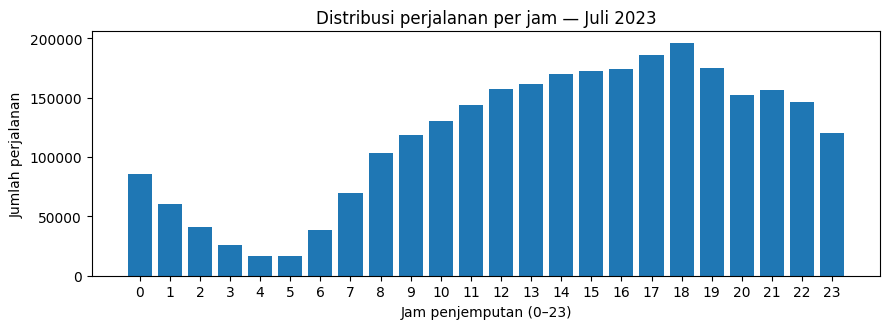

In [35]:
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi_juli["jam"], agregasi_juli["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0–23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam — Juli 2023")
ax.set_xticks(range(24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam_2023-07.png", dpi=150)
plt.show()

## Q2 — Perbandingan Januari vs Juli

,jam,Januari,Juli,selisih_Juli_minus_Januari
0,0,82289,85987,3698
1,1,57766,59980,2214
2,2,40445,40812,367
3,3,26146,26000,-146
4,4,16618,16637,19
5,5,16940,16913,-27
6,6,42300,38422,-3878
7,7,84569,69358,-15211
8,8,114064,103647,-10417
9,9,127988,118788,-9200


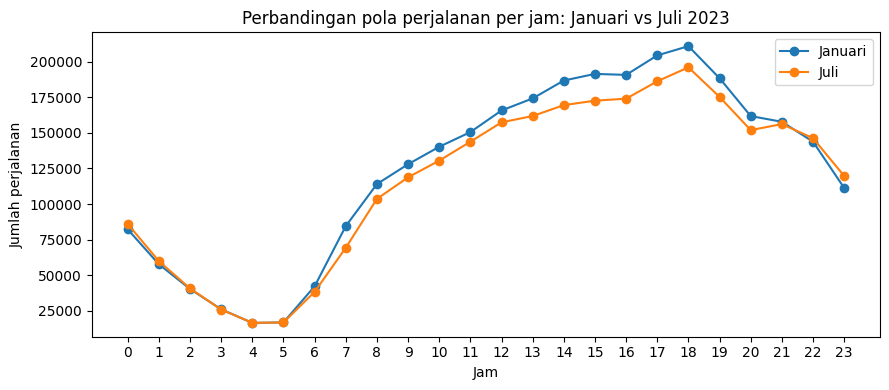

In [36]:
perbandingan_bulan = (
    agregasi[["jam", "jumlah_perjalanan"]]
    .rename(columns={"jumlah_perjalanan": "Januari"})
    .merge(
        agregasi_juli[["jam", "jumlah_perjalanan"]]
        .rename(columns={"jumlah_perjalanan": "Juli"}),
        on="jam",
        how="outer"
    )
    .fillna(0)
    .sort_values("jam")
)

perbandingan_bulan["selisih_Juli_minus_Januari"] = (
    perbandingan_bulan["Juli"] - perbandingan_bulan["Januari"]
)

display(perbandingan_bulan)

ax = perbandingan_bulan.set_index("jam")[["Januari", "Juli"]].plot(
    figsize=(9, 4), marker="o"
)
ax.set_title("Perbandingan pola perjalanan per jam: Januari vs Juli 2023")
ax.set_xlabel("Jam")
ax.set_ylabel("Jumlah perjalanan")
ax.set_xticks(range(24))
plt.tight_layout()
plt.savefig(f"{DIR_SIMPAN}/perbandingan_januari_juli.png", dpi=150)
plt.show()

## Q3 — Laporan kinerja

In [37]:
pengukuran_kinerja = pd.DataFrame(catatan).sort_values("detik", ascending=False)
display(pengukuran_kinerja)

termahal = pengukuran_kinerja.iloc[0]
print(
    f"Langkah paling mahal saat runtime ini: {termahal['langkah']} "
    f"({termahal['detik']} detik; delta RSS {termahal['delta_rss_mb']} MB)."
)
print(
    "Usulan percepatan konkret: kurangi I/O dan data yang dibaca dengan column pruning, "
    "gunakan Parquet, dan hindari konversi ke CSV kecuali memang diperlukan untuk eksperimen chunking."
)

pengukuran_kinerja.to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

,langkah,detik,delta_rss_mb
3,tulis CSV,39.27,5.8
5,spark count,8.05,0.0
7,spark agregasi,7.83,0.0
4,agregasi chunking,4.05,20.4
1,baca semua kolom,1.53,498.4
9,baca Juli 2023 kolom terpilih,0.90,192.0
2,baca kolom terpilih,0.58,204.6
6,spark count,0.34,0.0
8,unduh dataset Juli,0.34,0.0
0,unduh dataset,0.33,1.6


Langkah paling mahal saat runtime ini: tulis CSV (39.27 detik; delta RSS 5.8 MB).
Usulan percepatan konkret: kurangi I/O dan data yang dibaca dengan column pruning, gunakan Parquet, dan hindari konversi ke CSV kecuali memang diperlukan untuk eksperimen chunking.


# Pemeriksaan akhir artefak

In [38]:
print("File hasil di Google Drive:")
for nama in sorted(os.listdir(DIR_SIMPAN)):
    print("-", nama)

print("\nNotebook selesai. Simpan notebook dengan output sebelum dikumpulkan.")

File hasil di Google Drive:
- Laporan_Praktikum_BigData_P01_<NIM>.pdf
- agregasi_per_jam.csv
- agregasi_per_jam.parquet
- agregasi_per_jam_2023-07.csv
- agregasi_per_jam_2023-07.parquet
- bersih_gzip.parquet
- bersih_snappy.parquet
- distribusi_per_jam.png
- distribusi_per_jam_2023-07.png
- pengukuran_kinerja.csv
- perbandingan_januari_juli.png
- perbandingan_januari_juli_per_jam.csv
- rekomendasi_studi_kasus.txt
- studi_kasus_harikerja_vs_akhirpekan.png
- studi_kasus_tarif_per_menit.png
- studi_kasus_weekday_weekend.png

Notebook selesai. Simpan notebook dengan output sebelum dikumpulkan.
